In [1]:
from google.colab import drive
drive.flush_and_unmount()
print("Unmounted")

Drive not mounted, so nothing to flush and unmount.
Unmounted


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Remounted")

Mounted at /content/drive
Remounted


In [3]:
!git clone -b transfer_learning https://github.com/NicoReit54/ML_TU_WS25.git

Cloning into 'ML_TU_WS25'...
remote: Enumerating objects: 53259, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 53259 (delta 6), reused 16 (delta 3), pack-reused 53156 (from 2)
Receiving objects: 100% (53259/53259), 769.08 MiB | 30.46 MiB/s, done.
Resolving deltas: 100% (883/883), done.
Updating files: 100% (52111/52111), done.


In [5]:
import os
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Get the current working directory in Colab, usually /content
current_colab_cwd = os.getcwd()
print(f"Current Colab working directory: {current_colab_cwd}")

project_root_path = None
target_subdirectories = ['data', 'analysis', 'deep_learning']

# Walk through MyDrive to find the 'Exercise3' folder
for dirpath, dirnames, _ in os.walk('/content/'):
    # Check if 'Exercise3' is a subdirectory of the current dirpath
    if 'Exercise3' in dirnames:
        potential_project_root = os.path.join(dirpath, 'Exercise3')
        # Check if this potential root contains all target subdirectories
        if all(os.path.isdir(os.path.join(potential_project_root, sub_dir)) for sub_dir in target_subdirectories):
            project_root_path = potential_project_root
            break
    if Path(dirpath).name == 'Exercise3':
        if all(os.path.isdir(os.path.join(dirpath, sub_dir)) for sub_dir in target_subdirectories):
            project_root_path = dirpath
            break

if project_root_path:
    sys.path.append(project_root_path)
    print(f"Added project root to sys.path: {project_root_path}")
else:
    print("Warning: Could not automatically find the project root ('Exercise3' folder with 'data', 'analysis', 'deep_learning' subdirectories) in Google Drive.")
    print("Please ensure your project structure is correct and the 'Exercise3' folder is accessible in /content/drive/MyDrive.")
    print("You may need to manually adjust `sys.path.append()` to the correct path, e.g., `sys.path.append('/content/drive/MyDrive/YourFolder/Exercise3')`")

# Now try to import
try:
    from data.load_cifar import CIFAR10
    from data.load_gtsrb import GTSRB, GTSRB_CLASSES
    from analysis.evaluation import evaluate_model
    from deep_learning.cnn_transfer_learning import EfficientNetTransferModel
    from deep_learning.train_transfer_learning import (
        prepare_cifar10_loaders,
        prepare_gtsrb_loaders,
        train_transfer_learning
    )
    print("Modules imported successfully!")
except ModuleNotFoundError as e:
    print(f"Error importing modules even after path modification: {e}")
    print("Please double-check the 'Exercise3' folder structure and its location in Google Drive.")


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else
                     "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Create the outputs directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

Current Colab working directory: /content
Added project root to sys.path: /content/ML_TU_WS25/Exercise3
Modules imported successfully!
Using device: cuda


# CIFAR SECTION


Training samples: 50000
Test samples: 10000
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 160MB/s]


Total params: 4,020,358
Trainable params: 4,020,358

STAGE 1: Training classifier head (frozen backbone)

Epoch 1/5


Train Loss: 0.9541 | Train Acc: 0.7002
Train Time: 171.07s
Val   Loss: 0.6185 | Val   Acc: 0.8018
Val   Time: 20.31s

Epoch 2/5


Train Loss: 0.7526 | Train Acc: 0.7475
Train Time: 167.03s
Val   Loss: 0.5683 | Val   Acc: 0.8106
Val   Time: 19.91s

Epoch 3/5


...

Train Loss: 0.3371 | Train Acc: 0.8837
Train Time: 166.20s
Val   Loss: 0.2702 | Val   Acc: 0.9070
Val   Time: 19.83s
✓ New best model saved! Val Acc: 0.9070

Epoch 12/15


Train Loss: 0.3227 | Train Acc: 0.8874
Train Time: 166.14s
Val   Loss: 0.2675 | Val   Acc: 0.9089
Val   Time: 21.10s
✓ New best model saved! Val Acc: 0.9089

Epoch 13/15


Train Loss: 0.3172 | Train Acc: 0.8893
Train Time: 166.28s
Val   Loss: 0.2639 | Val   Acc: 0.9097
Val   Time: 20.13s
✓ New best model saved! Val Acc: 0.9097

Epoch 14/15


Train Loss: 0.3170 | Train Acc: 0.8878
Train Time: 166.75s
Val   Loss: 0.2642 | Val   Acc: 0.9092
Val   Time: 20.96s

Epoch 15/15


Train Loss: 0.3062 | Train Acc: 0.8919
Train Time: 167.28s
Val   Loss: 0.2603 | Val   Acc: 0.9108
Val   Time: 19.98s
✓ New best model saved! Val Acc: 0.9108

Total Training Time  : 2517.22s
Total Validation Time: 311.31s
Training curves saved to transfer_learning_curves/training_curves_EfficientNetB0_1769021573.png


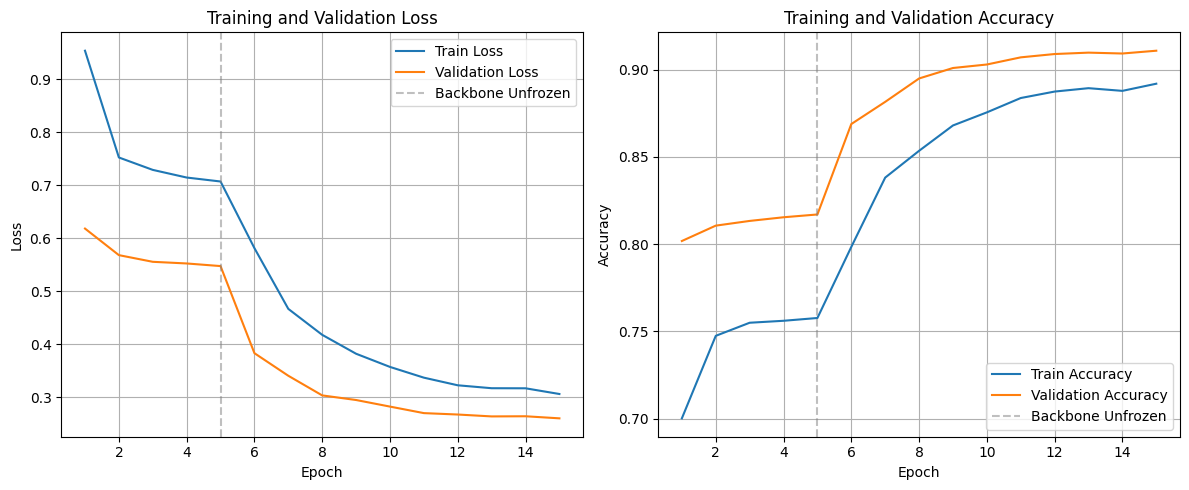


Best validation accuracy: 0.9108


In [6]:
# --- CIFAR 5 frozen & 10 unfrozen model ---

# Load data
train_loader, test_loader, class_names = prepare_cifar10_loaders(
    batch_size=64,
    num_workers=2
)

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

# Create model
model = EfficientNetTransferModel(
    num_classes=10,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs_frozen=5,
    epochs_unfrozen=10,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_cifar10.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")


EfficientNet-B0 on CIFAR-10
---------------------------
Overall accuracy: 0.9108

Per-class accuracy:
  airplane: 0.926
automobile: 0.948
      bird: 0.890
       cat: 0.768
      deer: 0.902
       dog: 0.893
      frog: 0.943
     horse: 0.956
      ship: 0.935
     truck: 0.947

Classification report:
              precision    recall  f1-score   support

    airplane      0.924     0.926     0.925      1000
  automobile      0.940     0.948     0.944      1000
        bird      0.912     0.890     0.901      1000
         cat      0.864     0.768     0.813      1000
        deer      0.893     0.902     0.898      1000
         dog      0.849     0.893     0.870      1000
        frog      0.924     0.943     0.933      1000
       horse      0.920     0.956     0.938      1000
        ship      0.943     0.935     0.939      1000
       truck      0.936     0.947     0.941      1000

    accuracy                          0.911     10000
   macro avg      0.911     0.911     0.910

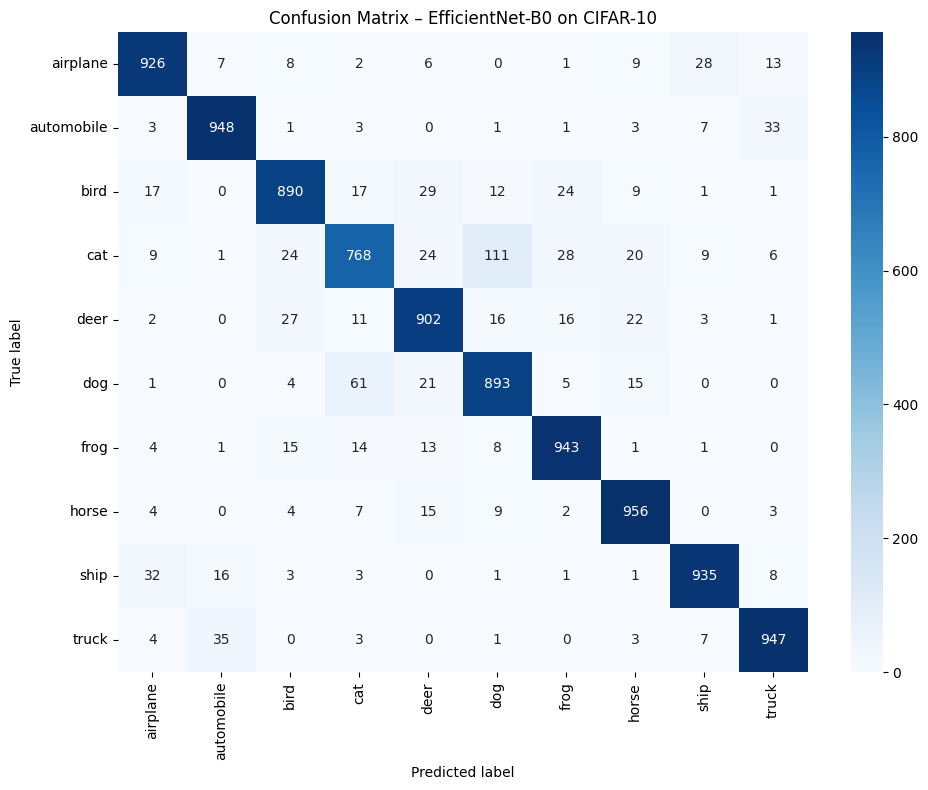


Overall Accuracy: 0.9108


In [7]:
# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_cifar10.pth', map_location=device))

# Evaluate with confusion matrix
results = evaluate_model(
    model=model,
    dataloader=test_loader,
    class_names=class_names,
    device=str(device),
    title="EfficientNet-B0 on CIFAR-10"
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")

Training samples: 50000
Test samples: 10000
Total params: 4,020,358
Trainable params: 4,020,358

STAGE 1: Training classifier head (frozen backbone)

Epoch 1/10


Train Loss: 0.9549 | Train Acc: 0.7007
Train Time: 162.24s
Val   Loss: 0.6218 | Val   Acc: 0.7990
Val   Time: 18.66s

Epoch 2/10


Train Loss: 0.7556 | Train Acc: 0.7465
Train Time: 164.33s
Val   Loss: 0.5747 | Val   Acc: 0.8063
Val   Time: 18.58s

Epoch 3/10


Train Loss: 0.7377 | Train Acc: 0.7500
Train Time: 163.54s
Val   Loss: 0.5483 | Val   Acc: 0.8155
Val   Time: 18.65s

Epoch 4/10


Train Loss: 0.7267 | Train Acc: 0.7538
Train Time: 162.53s
Val   Loss: 0.5410 | Val   Acc: 0.8196
Val   Time: 20.16s

Epoch 5/10


...

Train Loss: 0.7078 | Train Acc: 0.7581
Train Time: 165.75s
Val   Loss: 0.5286 | Val   Acc: 0.8223
Val   Time: 18.34s

Epoch 7/10


Train Loss: 0.7061 | Train Acc: 0.7592
Train Time: 163.40s
Val   Loss: 0.5233 | Val   Acc: 0.8253
Val   Time: 18.31s

Epoch 8/10


Train Loss: 0.7014 | Train Acc: 0.7594
Train Time: 162.51s
Val   Loss: 0.5251 | Val   Acc: 0.8196
Val   Time: 19.07s

Epoch 9/10


Train Loss: 0.6920 | Train Acc: 0.7635
Train Time: 162.79s
Val   Loss: 0.5178 | Val   Acc: 0.8252
Val   Time: 19.75s

Epoch 10/10


Train Loss: 0.6916 | Train Acc: 0.7638
Train Time: 162.85s
Val   Loss: 0.5285 | Val   Acc: 0.8236
Val   Time: 18.80s

STAGE 2: Fine-tuning last layers

Total Training Time  : 1632.37s
Total Validation Time: 188.77s
Training curves saved to transfer_learning_curves/training_curves_EfficientNetB0_1769023416.png


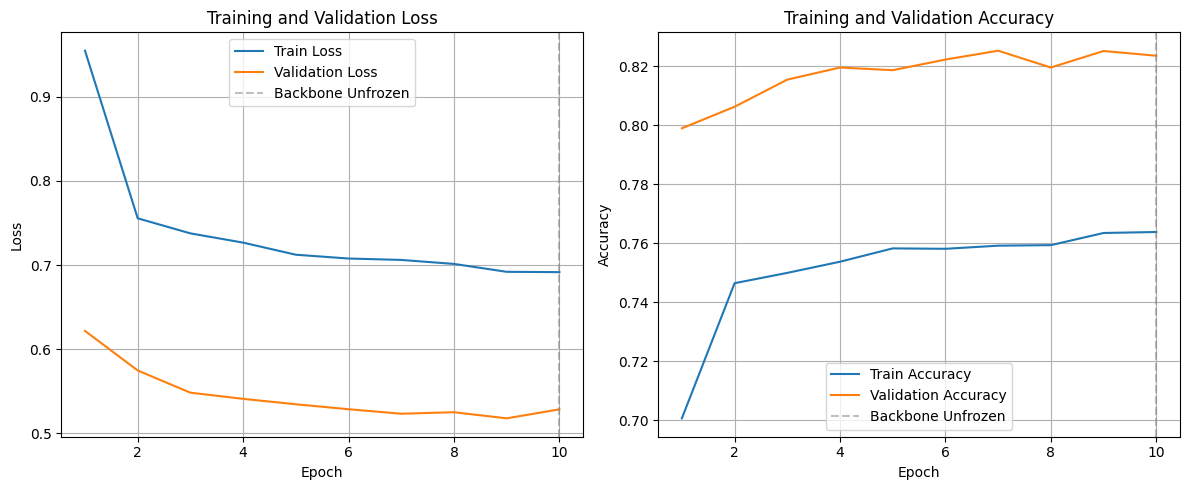


Best validation accuracy: 0.8253


In [8]:
# --- CIFAR 10 frozen model ---

# Load data
train_loader, test_loader, class_names = prepare_cifar10_loaders(
    batch_size=64,
    num_workers=2
)

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

# Create model
model = EfficientNetTransferModel(
    num_classes=10,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs_frozen=10,
    epochs_unfrozen=0,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_cifar10_no_unfreeze.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

In [10]:
torch.save(model.state_dict(), 'outputs/efficientnet_cifar10_no_unfreeze.pth')



EfficientNet-B0 on CIFAR-10 without unfreezing
----------------------------------------------
Overall accuracy: 0.8236

Per-class accuracy:
  airplane: 0.844
automobile: 0.884
      bird: 0.787
       cat: 0.593
      deer: 0.776
       dog: 0.836
      frog: 0.901
     horse: 0.883
      ship: 0.838
     truck: 0.894

Classification report:
              precision    recall  f1-score   support

    airplane      0.830     0.844     0.837      1000
  automobile      0.868     0.884     0.876      1000
        bird      0.791     0.787     0.789      1000
         cat      0.798     0.593     0.680      1000
        deer      0.813     0.776     0.794      1000
         dog      0.750     0.836     0.791      1000
        frog      0.830     0.901     0.864      1000
       horse      0.834     0.883     0.858      1000
        ship      0.877     0.838     0.857      1000
       truck      0.846     0.894     0.869      1000

    accuracy                          0.824     10000
   ma

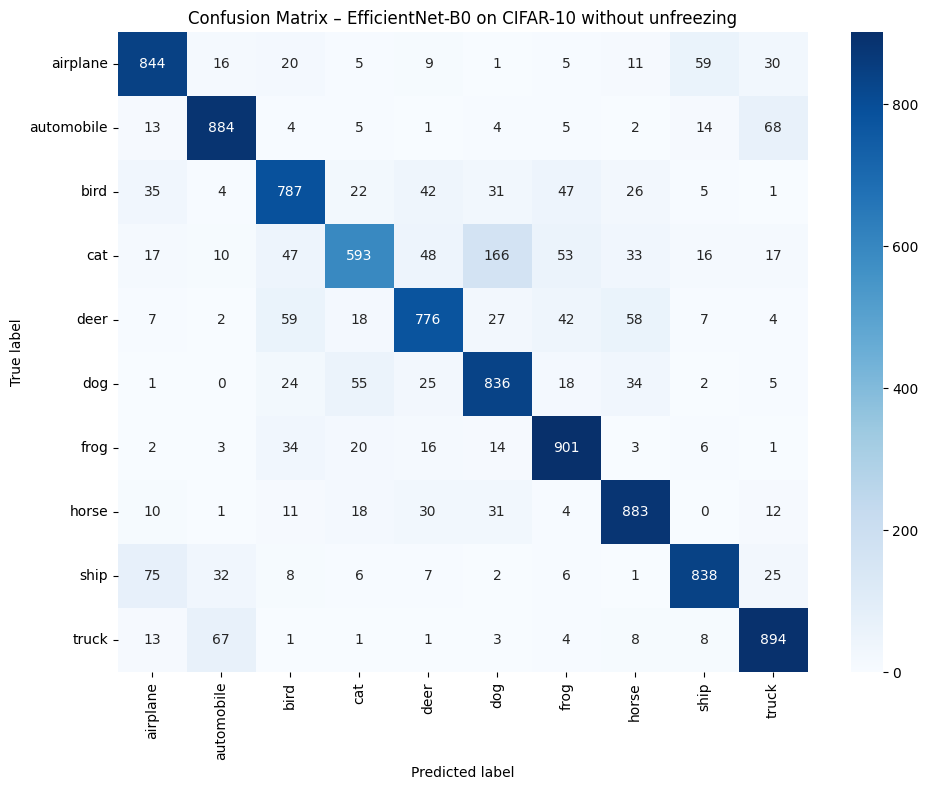


Overall Accuracy: 0.8236


In [11]:
# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_cifar10_no_unfreeze.pth', map_location=device))

# Evaluate with confusion matrix
results = evaluate_model(
    model=model,
    dataloader=test_loader,
    class_names=class_names,
    device=str(device),
    title="EfficientNet-B0 on CIFAR-10 without unfreezing"
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")

# GTSRB SECTION

In [12]:
# --- Loading in GTSRB ---
# Load data DIRECTLY like your colleague
from data.load_gtsrb import GTSRB
from deep_learning.train_transfer_learning import get_gtsrb_augmentation, get_test_transform

gtsrb_data_dir = '/content/ML_TU_WS25/Exercise3/data/GTSRB'
print(f"Using GTSRB data directory: {gtsrb_data_dir}")

train_path = os.path.join(gtsrb_data_dir, "Final_Training/Images")
test_path = os.path.join(gtsrb_data_dir, "Final_Test/Images")

train_ds = GTSRB(base_path=train_path, split="train", sample_fraction=1.0, transform=get_gtsrb_augmentation())
test_ds = GTSRB(base_path=test_path, split="test", sample_fraction=1.0, transform=get_test_transform())

gtsrb_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
gtsrb_test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_ds)}")  # Should be 39,209
print(f"Test samples: {len(test_ds)}")      # Should be 12,630

Using GTSRB data directory: /content/ML_TU_WS25/Exercise3/data/GTSRB
Loading GTSRB (train) from /content/ML_TU_WS25/Exercise3/data/GTSRB/Final_Training/Images...
Loading GTSRB (test) from /content/ML_TU_WS25/Exercise3/data/GTSRB/Final_Test/Images...
Training samples: 39209
Test samples: 12630


In [13]:
# --- VALIDATING GTSRB ---

train_path = os.path.join(gtsrb_data_dir, "Final_Training/Images")

# Count folders (classes)
class_folders = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Number of class folders: {len(class_folders)}")

# Count total images
total_images = 0
for class_folder in class_folders:
    class_path = os.path.join(train_path, class_folder)
    img_files = [f for f in os.listdir(class_path) if f.endswith(('.ppm', '.png', '.jpg'))]
    total_images += len(img_files)
    if len(img_files) < 100:  # Check if any class has suspiciously few images
        print(f"Class {class_folder}: {len(img_files)} images")

print(f"\nTotal images in filesystem: {total_images}")
print(f"Your dataset loading: {len(train_ds)}")
print(f"Missing: {total_images - len(train_ds)} images")

Number of class folders: 43

Total images in filesystem: 39209
Your dataset loading: 39209
Missing: 0 images


GTSRB TRAINING
Total params: 4,062,631
Trainable params: 4,062,631

STAGE 1: Training classifier head (frozen backbone)

Epoch 1/5


Train Loss: 1.6418 | Train Acc: 0.5552
Train Time: 301.61s
Val   Loss: 1.3610 | Val   Acc: 0.6181
Val   Time: 27.67s

Epoch 2/5


Train Loss: 1.0804 | Train Acc: 0.6774
Train Time: 303.14s
Val   Loss: 1.2221 | Val   Acc: 0.6380
Val   Time: 27.58s

Epoch 3/5


Train Loss: 0.9580 | Train Acc: 0.7083
Train Time: 302.83s
Val   Loss: 1.1515 | Val   Acc: 0.6586
Val   Time: 27.60s

Epoch 4/5


Train Loss: 0.9154 | Train Acc: 0.7200
Train Time: 305.10s
Val   Loss: 1.1187 | Val   Acc: 0.6658
Val   Time: 27.28s

Epoch 5/5


...

Train Loss: 0.2173 | Train Acc: 0.9302
Train Time: 305.81s
Val   Loss: 0.4193 | Val   Acc: 0.8633
Val   Time: 27.44s
✓ New best model saved! Val Acc: 0.8633

Epoch 12/15


Train Loss: 0.1995 | Train Acc: 0.9366
Train Time: 303.31s
Val   Loss: 0.4119 | Val   Acc: 0.8656
Val   Time: 27.55s
✓ New best model saved! Val Acc: 0.8656

Epoch 13/15


Train Loss: 0.1898 | Train Acc: 0.9392
Train Time: 302.38s
Val   Loss: 0.3734 | Val   Acc: 0.8774
Val   Time: 27.34s
✓ New best model saved! Val Acc: 0.8774

Epoch 14/15


Train Loss: 0.1835 | Train Acc: 0.9416
Train Time: 303.65s
Val   Loss: 0.3955 | Val   Acc: 0.8705
Val   Time: 27.41s

Epoch 15/15


Train Loss: 0.1817 | Train Acc: 0.9428
Train Time: 303.16s
Val   Loss: 0.4009 | Val   Acc: 0.8689
Val   Time: 27.42s

Total Training Time  : 4550.06s
Total Validation Time: 410.97s
Training curves saved to transfer_learning_curves/training_curves_EfficientNetB0_1769029059.png


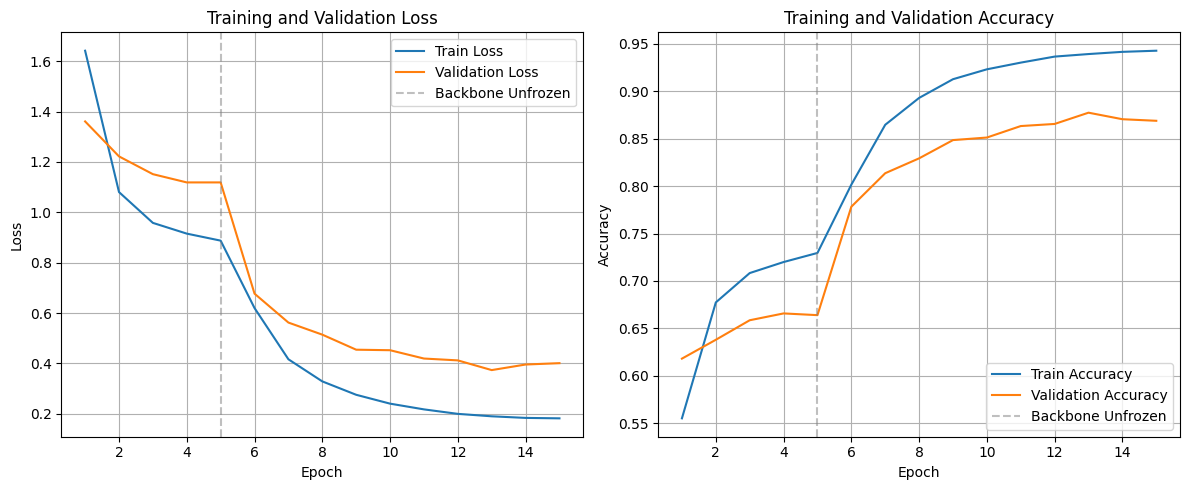


Best validation accuracy: 0.8774


In [14]:
# --- GTSRB 5 frozen & 10 unfrozen model ---

print("="*70)
print("GTSRB TRAINING")
print("="*70)

# Create model for 43 classes (GTSRB)
model = EfficientNetTransferModel(
    num_classes=43,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train with GTSRB loaders
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=gtsrb_train_loader,
    test_loader=gtsrb_test_loader,
    device=device,
    epochs_frozen=5,
    epochs_unfrozen=10,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_gtsrb.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

In [ ]:
torch.save(model.state_dict(), 'outputs/efficientnet_gtsrb.pth')


GTSRB EVALUATION

EfficientNet-B0 on GTSRB
------------------------
Overall accuracy: 0.8774

Per-class accuracy:
  Speed 20: 0.283
  Speed 30: 0.801
  Speed 50: 0.888
  Speed 60: 0.764
  Speed 70: 0.898
  Speed 80: 0.897
End Speed 80: 0.853
 Speed 100: 0.904
 Speed 120: 0.900
No passing: 0.944
No passing >3.5t: 0.982
Right-of-way: 0.883
Priority road: 0.987
     Yield: 0.990
      Stop: 0.989
No vehicles: 0.990
Veh >3.5t prohib: 0.940
  No entry: 0.947
General caution: 0.854
Curve left: 0.650
Curve right: 0.578
Double curve: 0.622
Bumpy road: 0.742
  Slippery: 0.787
Narrows right: 0.700
 Road work: 0.846
Traffic signals: 0.872
Pedestrians: 0.600
  Children: 0.720
  Bicycles: 0.933
  Ice/Snow: 0.753
Wild animals: 0.930
End limits: 0.900
Turn right: 0.757
 Turn left: 0.708
Ahead only: 0.918
Straight/Right: 0.592
Straight/Left: 0.333
Keep right: 0.977
 Keep left: 0.456
Roundabout: 0.833
End no passing: 0.833
End no pass >3.5t: 0.722

Classification report:
                   precision   

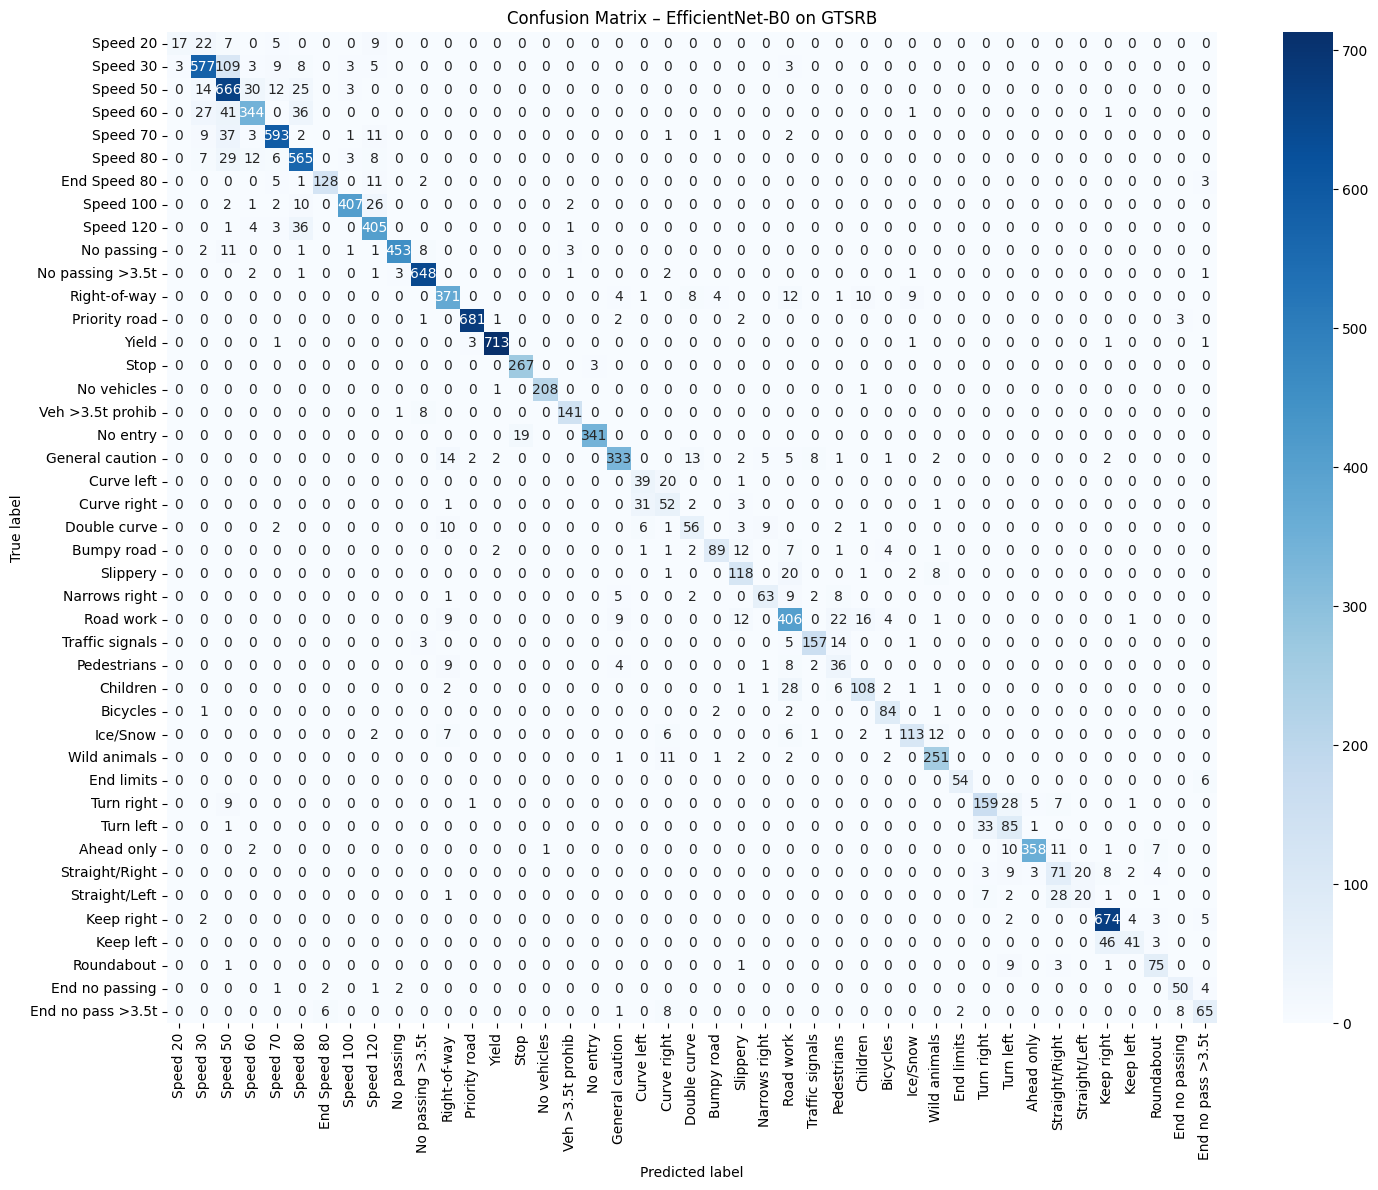


Overall Accuracy: 0.8774


In [15]:
print("="*70)
print("GTSRB EVALUATION")
print("="*70)

# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_gtsrb.pth', map_location=device))

# Define gtsrb_class_names from the GTSRB_CLASSES dictionary
gtsrb_class_names = list(GTSRB_CLASSES.values())

# Evaluate with GTSRB data
results = evaluate_model(
    model=model,
    dataloader=gtsrb_test_loader,
    class_names=gtsrb_class_names,
    device=str(device),
    title="EfficientNet-B0 on GTSRB",
    figsize=(15, 12)
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")

In [ ]:
# --- GTSRB 10 frozen model ---

print("="*70)
print("GTSRB NO UNFREEZING TRAINING")
print("="*70)

# Create model for 43 classes (GTSRB)
model = EfficientNetTransferModel(
    num_classes=43,
    dropout=0.3,
    pretrained=True
)
print(f"Total params: {model.get_total_params():,}")
print(f"Trainable params: {model.get_trainable_params():,}")

# Train with GTSRB loaders
model, best_acc, history = train_transfer_learning(
    model=model,
    train_loader=gtsrb_train_loader,  # GTSRB data
    test_loader=gtsrb_test_loader,    # GTSRB data
    device=device,
    epochs_frozen=10,
    epochs_unfrozen=0,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4,
    save_path='outputs/efficientnet_gtsrb_no_unfreeze.pth'
)

print(f"\nBest validation accuracy: {best_acc:.4f}")

In [ ]:
print("="*70)
print("GTSRB FROZEN EVALUATION")
print("="*70)

# Load best model
model.load_state_dict(torch.load('outputs/efficientnet_gtsrb_no_unfreeze.pth', map_location=device))

# Define gtsrb_class_names from the GTSRB_CLASSES dictionary
gtsrb_class_names = list(GTSRB_CLASSES.values())

# Evaluate with GTSRB data
results = evaluate_model(
    model=model,
    dataloader=gtsrb_test_loader,
    class_names=gtsrb_class_names,
    device=str(device),
    title="EfficientNet-B0 on GTSRB without unfreezing",
    figsize=(15, 12)
)

print(f"\nOverall Accuracy: {results['overall_accuracy']:.4f}")